In [93]:
#Cell 1, Load raw NBA data


import pandas as pd
import numpy as np


# Replace this with the actual path to your CSV file
file_path = r"C:\Users\mikey\Desktop\Data Science projects\NBA ALL STAR\2015-2025\nba_2015_2025_cleaned.csv"

# Load the data
nba_df = pd.read_csv(file_path)

# Confirm it worked
print("Shape:", nba_df.shape)
print("Years in dataset:", sorted(nba_df["Year"].unique()))
nba_df.head()




Shape: (3807, 32)
Years in dataset: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


,Rk,Player,Age,Team,Pos,G,GS,MP,FG,FGA,...,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,Awards,Year
0,276.0,A.J. Green,25.0,MIL,SG,73.0,7.0,22.7,2.5,5.8,...,2.1,2.4,1.5,0.5,0.1,0.5,2.2,7.4,NaN,2025
1,218.0,A.J. Lawson,24.0,TOR,SG,26.0,2.0,18.7,3.1,7.3,...,2.5,3.3,1.2,0.5,0.2,0.6,1.7,9.1,NaN,2025
2,217.0,AJ Griffin,19.0,ATL,SF,72.0,12.0,19.5,3.4,7.4,...,1.6,2.1,1.0,0.6,0.2,0.6,1.2,8.9,NaN,2023
3,271.0,AJ Johnson,20.0,WAS,SG,22.0,11.0,27.0,3.4,8.8,...,2.0,2.4,3.1,0.5,0.1,1.4,2.3,9.1,NaN,2025
4,124.0,Aaron Brooks,30.0,CHI,PG,82.0,21.0,23.0,4.2,10.0,...,1.6,2.0,3.2,0.7,0.2,1.9,2.3,11.6,NaN,2015


In [1]:
# Cell 1b, TS% 


import pandas as pd

years = list(range(2015, 2026))
adv_seasons = []

for year in years:
    print(f"Loading advanced stats for {year}...")
    url = f"https://www.basketball-reference.com/leagues/NBA_{year}_advanced.html"
    try:
        df_adv = pd.read_html(url, header=0)[0]

        # Clean column names: lowercase + strip whitespace
        df_adv.columns = df_adv.columns.str.lower().str.strip()

        # Print columns to debug if 'player' not found
        if 'player' not in df_adv.columns:
            print(f"❌ Column 'player' not found in {year}. Columns are:")
            print(df_adv.columns.tolist())
            continue

        # Remove repeated headers
        df_adv = df_adv[df_adv['player'] != 'Player']

        # Convert TS% to numeric
        df_adv['ts%'] = pd.to_numeric(df_adv['ts%'], errors='coerce')

        # Add year
        df_adv['year'] = year

        # Store necessary columns
        adv_seasons.append(df_adv[['player', 'year', 'ts%']])

    except Exception as e:
        print(f"⚠️ Could not load TS% for {year}: {e}")

# Combine all years
if adv_seasons:
    adv_df = pd.concat(adv_seasons, ignore_index=True)
    adv_df.columns = ['Player', 'Year', 'TS%']  # rename to match nba_df
    print("✅ Advanced stats loaded:", adv_df.shape)
    display(adv_df.head())
else:
    print("❌ No advanced stats loaded.")



Loading advanced stats for 2015...
⚠️ Could not load TS% for 2015: HTTP Error 429: Too Many Requests
Loading advanced stats for 2016...
⚠️ Could not load TS% for 2016: HTTP Error 429: Too Many Requests
Loading advanced stats for 2017...
⚠️ Could not load TS% for 2017: HTTP Error 429: Too Many Requests
Loading advanced stats for 2018...
⚠️ Could not load TS% for 2018: HTTP Error 429: Too Many Requests
Loading advanced stats for 2019...
⚠️ Could not load TS% for 2019: HTTP Error 429: Too Many Requests
Loading advanced stats for 2020...
⚠️ Could not load TS% for 2020: HTTP Error 429: Too Many Requests
Loading advanced stats for 2021...
⚠️ Could not load TS% for 2021: HTTP Error 429: Too Many Requests
Loading advanced stats for 2022...
⚠️ Could not load TS% for 2022: HTTP Error 429: Too Many Requests
Loading advanced stats for 2023...
⚠️ Could not load TS% for 2023: HTTP Error 429: Too Many Requests
Loading advanced stats for 2024...
⚠️ Could not load TS% for 2024: HTTP Error 429: Too Many

In [95]:
#Cell 1c, Team Wins


import pandas as pd

team_wins_list = []

team_abbr_map = {
    'Atlanta Hawks': 'ATL', 'Boston Celtics': 'BOS', 'Brooklyn Nets': 'BRK', 'Charlotte Hornets': 'CHA',
    'Chicago Bulls': 'CHI', 'Cleveland Cavaliers': 'CLE', 'Dallas Mavericks': 'DAL', 'Denver Nuggets': 'DEN',
    'Detroit Pistons': 'DET', 'Golden State Warriors': 'GSW', 'Houston Rockets': 'HOU', 'Indiana Pacers': 'IND',
    'Los Angeles Clippers': 'LAC', 'Los Angeles Lakers': 'LAL', 'Memphis Grizzlies': 'MEM', 'Miami Heat': 'MIA',
    'Milwaukee Bucks': 'MIL', 'Minnesota Timberwolves': 'MIN', 'New Orleans Pelicans': 'NOP', 'New York Knicks': 'NYK',
    'Oklahoma City Thunder': 'OKC', 'Orlando Magic': 'ORL', 'Philadelphia 76ers': 'PHI', 'Phoenix Suns': 'PHO',
    'Portland Trail Blazers': 'POR', 'Sacramento Kings': 'SAC', 'San Antonio Spurs': 'SAS', 'Toronto Raptors': 'TOR',
    'Utah Jazz': 'UTA', 'Washington Wizards': 'WAS'
}

for year in range(2015, 2026):
    print(f"Scraping team wins for {year}...")
    url = f"https://www.basketball-reference.com/leagues/NBA_{year}_standings.html"
    try:
        tables = pd.read_html(url)
        east_df = tables[0]
        west_df = tables[1]

        for conf_df in [east_df, west_df]:
            for _, row in conf_df.iterrows():
                team_name = row.iloc[0].replace("*", "").strip()
                wins = row.iloc[1]

                if team_name in team_abbr_map:
                    team_wins_list.append({'Year': year, 'Team': team_abbr_map[team_name], 'TeamWins': int(wins)})
    except Exception as e:
        print(f"⚠️ Error scraping {year}: {e}")

team_wins_df = pd.DataFrame(team_wins_list)

print("✅ Team Wins loaded:", team_wins_df.shape)
display(team_wins_df.head())




Scraping team wins for 2015...
⚠️ Error scraping 2015: HTTP Error 429: Too Many Requests
Scraping team wins for 2016...
⚠️ Error scraping 2016: HTTP Error 429: Too Many Requests
Scraping team wins for 2017...
⚠️ Error scraping 2017: HTTP Error 429: Too Many Requests
Scraping team wins for 2018...
⚠️ Error scraping 2018: HTTP Error 429: Too Many Requests
Scraping team wins for 2019...
⚠️ Error scraping 2019: HTTP Error 429: Too Many Requests
Scraping team wins for 2020...
⚠️ Error scraping 2020: HTTP Error 429: Too Many Requests
Scraping team wins for 2021...
⚠️ Error scraping 2021: HTTP Error 429: Too Many Requests
Scraping team wins for 2022...
⚠️ Error scraping 2022: HTTP Error 429: Too Many Requests
Scraping team wins for 2023...
⚠️ Error scraping 2023: HTTP Error 429: Too Many Requests
Scraping team wins for 2024...
⚠️ Error scraping 2024: HTTP Error 429: Too Many Requests
Scraping team wins for 2025...
⚠️ Error scraping 2025: HTTP Error 429: Too Many Requests
✅ Team Wins loaded: (

""


In [96]:
# Cell 2: Clean data


import numpy as np
import pandas as pd

# === Step 1: Sort and filter ===
nba_df = nba_df.sort_values(['Player', 'Year', 'Team'])  # 'TOT' comes last
nba_df = nba_df.drop_duplicates(subset=['Player', 'Year'], keep='last')  # keep only 'TOT' or last team
nba_df = nba_df[nba_df['MP'] >= 15].reset_index(drop=True)

print("✅ Players per year after filtering:")
print(nba_df['Year'].value_counts().sort_index())

# === Step 2: Clean existing columns before merging ===
for col in ['TS%', 'TS%_x', 'TS%_y', 'TeamWins', 'TeamWins_x', 'TeamWins_y']:
    if col in nba_df.columns:
        nba_df.drop(columns=col, inplace=True)

# === Step 3: Normalize Team Names Before Merge ===
team_aliases = {
    "BRK": "BKN",
    "PHO": "PHX",
    "GS": "GSW",
    "SA": "SAS",
    "NY": "NYK",
    "NOH": "NOP",
    "BOB": "CHA",
    "CHB": "CHA",
    "NJN": "BKN",
    "SEA": "OKC",
    "GS": "GSW",
    "NJ": "BKN",
    "WSH": "WAS",
    "UTH": "UTA",
    "CHH": "CHA",
    "VAN": "MEM",
    "SD": "LAC",  # San Diego Clippers → LAC
}

# === Manually add 2025 projected TeamWins ===
manual_2025 = pd.DataFrame({
    'Year': [2025] * 30,
    'Team': [
        'CLE', 'BOS', 'NYK', 'IND', 'MIL', 'DET', 'ORL', 'ATL', 'CHI', 'MIA',
        'TOR', 'BRK', 'PHI', 'CHA', 'WAS',
        'OKC', 'HOU', 'LAL', 'DEN', 'LAC', 'MIN', 'GSW', 'MEM', 'SAC', 'DAL',
        'PHX', 'POR', 'SAS', 'NOP', 'UTA'
    ],
    'TeamWins': [
        64, 61, 51, 50, 48, 44, 41, 40, 39, 37,
        30, 26, 24, 19, 18,
        68, 52, 50, 50, 50, 49, 48, 48, 40, 39,
        36, 36, 34, 21, 17
    ]
})

# Add to team_wins_df
team_wins_df = pd.concat([team_wins_df, manual_2025], ignore_index=True)


# Apply team aliases
nba_df['Team'] = nba_df['Team'].replace(team_aliases)
team_wins_df['Team'] = team_wins_df['Team'].replace(team_aliases)

# Remove leading/trailing whitespace
nba_df['Team'] = nba_df['Team'].str.strip()
team_wins_df['Team'] = team_wins_df['Team'].str.strip()

# === Step 4: Merge external TS% and TeamWins onto non-TOT players ===
non_tot_df = nba_df[nba_df['Team'] != 'TOT'].copy()
non_tot_df = pd.merge(non_tot_df, adv_df, on=['Player', 'Year'], how='left')
non_tot_df = pd.merge(non_tot_df, team_wins_df, on=['Year', 'Team'], how='left')

# Recombine
tot_df = nba_df[nba_df['Team'] == 'TOT'].copy()
nba_df = pd.concat([non_tot_df, tot_df], ignore_index=True)
nba_df = nba_df.sort_values(['Player', 'Year']).reset_index(drop=True)

# === Step 5: Diagnostics ===
print("✅ Columns in nba_df:", nba_df.columns)
print("❗ Missing TeamWins after merge:", nba_df['TeamWins'].isna().sum())

print("✅ Sample rows with TeamWins & TS%:")
print(nba_df[['Player', 'Team', 'Year', 'MP', 'TS%', 'TeamWins']].sample(5))

# Inspect missing TeamWins rows
missing_teamwins = nba_df[nba_df['TeamWins'].isna()][['Player', 'Team', 'Year']].drop_duplicates()
print("❗ Missing TeamWins rows (unique Player-Team-Year):")
print(missing_teamwins.head(10))
print("\nTeam distribution in missing rows:")
print(missing_teamwins['Team'].value_counts())
print("\nYear distribution in missing rows:")
print(missing_teamwins['Year'].value_counts())

# === Step 6: Fill missing TeamWins from team_wins_df using map ===
team_wins_map = team_wins_df.set_index(['Year', 'Team'])['TeamWins'].to_dict()
nba_df['TeamWins'] = nba_df.apply(
    lambda row: team_wins_map.get((row['Year'], row['Team']), np.nan)
    if row['Team'] != 'TOT' else np.nan,
    axis=1
)

# === Step 7: Fill TOT rows with max TeamWins from non-TOT teams ===
teamwins_filled = (
    nba_df[~nba_df['Team'].eq('TOT') & ~nba_df['TeamWins'].isna()]
    .groupby(['Player', 'Year'])['TeamWins']
    .max()
    .reset_index(name='TeamWins_filled')
)
nba_df = pd.merge(nba_df, teamwins_filled, on=['Player', 'Year'], how='left')
nba_df['TeamWins'] = nba_df['TeamWins'].combine_first(nba_df['TeamWins_filled'])
nba_df.drop(columns=['TeamWins_filled'], inplace=True)

# === Step 8: Fill remaining missing with yearly median TeamWins ===
yearly_median_wins = team_wins_df.groupby('Year')['TeamWins'].median().to_dict()
nba_df['TeamWins'] = nba_df.apply(
    lambda row: yearly_median_wins.get(row['Year'], np.nan) if pd.isna(row['TeamWins']) else row['TeamWins'],
    axis=1
)

# === Step 9: Final Validation ===
missing_after = nba_df[nba_df['TeamWins'].isna()]
print("✅ Final missing TeamWins count:", len(missing_after))
if not missing_after.empty:
    print("❗ Still missing TeamWins for the following (likely team name mismatch or missing data):")
    print(missing_after[['Player', 'Team', 'Year']].drop_duplicates().head(10))

    # Save for manual review
    missing_after[['Player', 'Team', 'Year']].drop_duplicates().to_csv('unmatched_teams.csv', index=False)
    print("❗ Unmatched teams saved to 'unmatched_teams.csv' for review.")

    # Optional debug: missing team-year pairs
    missing_pairs = set(missing_after[['Year', 'Team']].itertuples(index=False, name=None))
    available_pairs = set(team_wins_df[['Year', 'Team']].itertuples(index=False, name=None))
    print("\n🔍 Missing (Year, Team) pairs:")
    for yt in sorted(missing_pairs - available_pairs):
        print(yt)

# Final check
print("✅ Final missing TeamWins count:", nba_df['TeamWins'].isna().sum())



✅ Players per year after filtering:
Year
2015    336
2016    319
2017    335
2018    350
2019    335
2020    335
2021    365
2022    378
2023    342
2024    338
2025    374
Name: count, dtype: int64
✅ Columns in nba_df: Index(['Rk', 'Player', 'Age', 'Team', 'Pos', 'G', 'GS', 'MP', 'FG', 'FGA',
       'FG%', '3P', '3PA', '3P%', '2P', '2PA', '2P%', 'eFG%', 'FT', 'FTA',
       'FT%', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS',
       'Awards', 'Year', 'TS%', 'TeamWins'],
      dtype='object')
❗ Missing TeamWins after merge: 4329
✅ Sample rows with TeamWins & TS%:
               Player Team  Year    MP    TS%  TeamWins
1054  Dejounte Murray  ATL  2023  36.4  0.540       NaN
3493    Nick Collison  OKC  2015  16.7  0.485       NaN
3867   Reggie Jackson  LAC  2020  21.3  0.492       NaN
2126  Jeff Dowtin Jr.  PHI  2025  15.1  0.570      24.0
1863       Jaden Ivey  DET  2023  31.1  0.528       NaN
❗ Missing TeamWins rows (unique Player-Team-Year):
          Player Team  Year


In [97]:
# Cell 4, Label AllStars from 2015 to 2025


# Dictionary of All-Star players by year (sample shown for 2023; you will need to continue filling this)
all_star_dict = {
    2015: ["Stephen Curry", "Kobe Bryant", "Anthony Davis", "Marc Gasol", "Blake Griffin", "James Harden", "Klay Thompson", "Chris Paul", "Russell Westbrook", "LaMarcus Aldridge", "Tim Duncan", "Kevin Durant", "Damian Lillard", "Dirk Nowitzki",
           "John Wall", "Kyle Lowry", "LeBron James", "Pau Gasol", "Carmelo Anthony", "Jimmy Butler", "Chris Bosh", "Paul Millsap", "Kyrie Irving", "Jeff Teague", "Al Horford", "DeMar DeRozan"],
    2016: ["Stephen Curry", "Russell Westbrook", "Kobe Bryant", "Kevin Durant", "Kawhi Leonard", "Chris Paul", "James Harden", "Klay Thompson", "Draymond Green", "Anthony Davis", "DeMarcus Cousins", "LaMarcus Aldridge",
           "LeBron James", "Paul George", "Carmelo Anthony", "Kyle Lowry", "Dwyane Wade", "DeMar DeRozan", "Jimmy Butler", "Isaiah Thomas", "Paul Millsap", "Andre Drummond", "John Wall", "Chris Bosh"],
    2017: ["Kyrie Irving", "DeMar DeRozan", "LeBron James", "Jimmy Butler", "Giannis Antetokounmpo", "Isaiah Thomas", "John Wall", "Kevin Love", "Kyle Lowry", "Paul George", "Kemba Walker", "Paul Millsap",
           "Stephen Curry", "James Harden", "Kevin Durant", "Kawhi Leonard", "Anthony Davis", "Russell Westbrook", "Klay Thompson", "Draymond Green", "DeMarcus Cousins", "Marc Gasol", "DeAndre Jordan", "Gordon Hayward"],
    2018: ["Kyrie Irving", "LeBron James", "Anthony Davis", "DeMarcus Cousins", "Kevin Durant", "LaMarcus Aldridge", "Bradley Beal", "Kevin Love", "Russell Westbrook", "Victor Oladipo", "Kristaps Porziņģis", "John Wall", "Paul George", "Andre Drummond", "Goran Dragić", "Kemba Walker",
           "James Harden", "DeMar DeRozan", "Stephen Curry", "Giannis Antetokounmpo", "Joel Embiid", "Damian Lillard", "Jimmy Butler", "Draymond Green", "Kyle Lowry", "Klay Thompson", "Karl-Anthony Towns", "Al Horford"],
    2019: ["Kemba Walker", "Kyrie Irving", "Kawhi Leonard", "Giannis Antetokounmpo", "Joel Embiid", "Kyle Lowry", "Victor Oladipo", "Khris Middleton", "Bradley Beal", "Ben Simmons", "Blake Griffin", "Nikola Vučević", "Dwyane Wade", "D'Angelo Russell",
       "Stephen Curry", "James Harden", "Kevin Durant", "Paul George", "LeBron James", "Russell Westbrook", "Damian Lillard", "Klay Thompson", "Anthony Davis", "LaMarcus Aldridge", "Nikola Jokić", "Karl-Anthony Towns", "Dirk Nowitzki"],
    2020: ["Kemba Walker", "Trae Young", "Giannis Antetokounmpo", "Pascal Siakam", "Joel Embiid", "Kyle Lowry", "Ben Simmons", "Jimmy Butler", "Khris Middleton", "Bam Adebayo", "Jayson Tatum", "Domantas Sabonis",
       "James Harden", "Luka Dončić", "LeBron James", "Kawhi Leonard", "Anthony Davis", "Chris Paul", "Russell Westbrook", "Damian Lillard", "Donovan Mitchell", "Brandon Ingram", "Nikola Jokić", "Rudy Gobert", "Devin Booker"],
    2021: ["Bradley Beal", "Kyrie Irving", "Giannis Antetokounmpo", "Kevin Durant", "Joel Embiid", "Jaylen Brown", "James Harden", "Zach LaVine", "Ben Simmons", "Julius Randle", "Domantas Sabonis", "Jayson Tatum", "Nikola Vučević",
       "Stephen Curry", "Luka Dončić", "LeBron James", "Kawhi Leonard", "Nikola Jokić", "Devin Booker", "Mike Conley", "Damian Lillard", "Donovan Mitchell", "Chris Paul", "Anthony Davis", "Paul George", "Zion Williamson", "Rudy Gobert"],
    2022: ["Trae Young", "DeMar DeRozan", "Joel Embiid", "Kevin Durant", "Giannis Antetokounmpo", "LaMelo Ball", "Darius Garland", "James Harden", "Zach LaVine", "Fred VanVleet", "Jimmy Butler", "Khris Middleton", "Jayson Tatum", "Jarrett Allen",
       "Stephen Curry", "Ja Morant", "Nikola Jokić", "LeBron James", "Andrew Wiggins", "Devin Booker", "Luka Dončić", "Donovan Mitchell", "Dejounte Murray", "Chris Paul", "Draymond Green", "Rudy Gobert", "Karl-Anthony Towns"],
    2023: ["Kyrie Irving", "Donovan Mitchell", "Giannis Antetokounmpo", "Kevin Durant", "Jayson Tatum", "Jaylen Brown", "DeMar DeRozan", "Tyrese Haliburton", "Jrue Holiday", "Julius Randle", "Bam Adebayo", "Joel Embiid", "Pascal Siakam",
       "Stephen Curry", "Luka Dončić", "Nikola Jokić", "LeBron James", "Zion Williamson", "Shai Gilgeous-Alexander", "Damian Lillard", "Ja Morant", "Paul George", "Jaren Jackson Jr.", "Lauri Markkanen", "Domantas Sabonis", "Anthony Edwards", "De'Aaron Fox"],
    2024: ["Tyrese Haliburton", "Damian Lillard", "Giannis Antetokounmpo", "Jayson Tatum", "Joel Embiid", "Jalen Brunson", "Tyrese Maxey", "Donovan Mitchell", "Trae Young", "Paolo Banchero", "Scottie Barnes", "Jaylen Brown", "Julius Randle", "Bam Adebayo",
       "Luka Dončić", "Shai Gilgeous-Alexander", "Kevin Durant", "LeBron James", "Nikola Jokić", "Devin Booker", "Stephen Curry", "Anthony Edwards", "Paul George", "Kawhi Leonard", "Karl-Anthony Towns", "Anthony Davis"],
    2025: ["Jalen Brunson", "Donovan Mitchell", "Jayson Tatum", "Giannis Antetokounmpo", "Karl-Anthony Towns", "Jaylen Brown", "Cade Cunningham", "Darius Garland", "Tyler Herro", "Damian Lillard", "Evan Mobley", "Pascal Siakam", "Trae Young",
       "Shai Gilgeous-Alexander", "Stephen Curry", "LeBron James", "Kevin Durant", "Nikola Jokić", "Anthony Edwards", "James Harden", "Jaren Jackson Jr.", "Jalen Williams", "Anthony Davis", "Alperen Şengün", "Victor Wembanyama", "Kyrie Irving"]

}

# 🔧 Function to assign All-Star labels
def label_all_stars(df, all_star_dict):
    df['AllStar'] = df.apply(
        lambda row: 1 if row['Player'] in all_star_dict.get(row['Year'], []) else 0,
        axis=1
    )
    return df

# ✅ Strip column names from nba_df (not a nonexistent 'df')
nba_df.columns = nba_df.columns.str.strip()

# 🏷️ Apply labeling function to cleaned data
df_labeled = label_all_stars(nba_df.copy(), all_star_dict)

# 🧾 Check labeled years
print("Years included after labeling:", sorted(df_labeled['Year'].unique()))

# 🔍 Preview labeled data
df_labeled[["Player", "Year", "AllStar"]].head(10)

Years included after labeling: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


,Player,Year,AllStar
0,A.J. Green,2025,0
1,A.J. Lawson,2025,0
2,AJ Griffin,2023,0
3,AJ Johnson,2025,0
4,AJ Johnson,2025,0
5,AJ Johnson,2025,0
6,Aaron Brooks,2015,0
7,Aaron Brooks,2016,0
8,Aaron Gordon,2015,0
9,Aaron Gordon,2016,0


In [98]:
# Cell 5 – Use only CustomScore for model input


from sklearn.model_selection import train_test_split

# ✅ Step 0 – Print years before cleanup
print("Years in df_labeled before cleaning:", sorted(df_labeled['Year'].unique()))

# ✅ Step 1 – Check for missing values
required_stats = ['PTS', 'AST', 'TRB', 'STL', 'BLK', 'MP']
print("Missing values by column:")
print(df_labeled[required_stats + ['AllStar']].isna().sum())

# ✅ Step 2 – Drop rows where CustomScore cannot be computed
df_labeled = df_labeled.dropna(subset=required_stats + ['AllStar'])

# ✅ Step 3 – Compute CustomScore
df_labeled['CustomScore'] = (
    df_labeled['PTS'] * 1.0 +
    df_labeled['AST'] * 2.0 +
    df_labeled['TRB'] * 1.2 +
    df_labeled['STL'] * 1.0 +
    df_labeled['BLK'] * 1.0 +
    df_labeled['MP'] * 0.1
)

# ✅ Step 4 – Confirm all years are present
print("Years remaining after cleaning:", sorted(df_labeled['Year'].unique()))

# ✅ Step 5 – Train/Test Split
X = df_labeled[['CustomScore']]
y = df_labeled['AllStar']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])

# ✅ Step 6 – Show average CustomScore per year in full df
print("Mean CustomScore by year (full data):")
print(df_labeled.groupby("Year")["CustomScore"].mean())



Years in df_labeled before cleaning: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
Missing values by column:
PTS        0
AST        0
TRB        0
STL        0
BLK        0
MP         0
AllStar    0
dtype: int64
Years remaining after cleaning: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
Training samples: 3836
Test samples: 959
Mean CustomScore by year (full data):
Year
2015    23.802276
2016    24.292827
2017    24.086772
2018    24.629327
2019    25.474552
2020    26.061741
2021    25.676609
2022    25.267725
2023    26.629065
2024    26.042176
2025    26.016577
Name: CustomScore, dtype: float64


In [99]:
# Cell 6: Training cell


from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Step 1: Ensure CustomScore is computed (if not already done)
if 'CustomScore' not in df_labeled.columns or df_labeled['CustomScore'].isnull().any():
    df_labeled['CustomScore'] = (
        df_labeled['PTS'] * 1.0 +
        df_labeled['AST'] * 2.0 +
        df_labeled['TRB'] * 1.2 +
        df_labeled['STL'] * 1.0 +
        df_labeled['BLK'] * 1.0 +
        df_labeled['MP'] * 0.1
    )

# Step 2: Drop rows with missing values in CustomScore or AllStar label
df_labeled = df_labeled.dropna(subset=['CustomScore', 'AllStar'])

# Step 3: Select feature and target
X = df_labeled[['CustomScore']]
y = df_labeled['AllStar']

# Step 4: Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Step 5: Train the model
model = LogisticRegression()
model.fit(X_train, y_train)

# Step 6: Evaluate model performance
y_pred = model.predict(X_test)
print("✅ Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))




✅ Logistic Regression Results
Accuracy: 0.9603753910323254
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       899
           1       0.72      0.60      0.65        60

    accuracy                           0.96       959
   macro avg       0.85      0.79      0.82       959
weighted avg       0.96      0.96      0.96       959



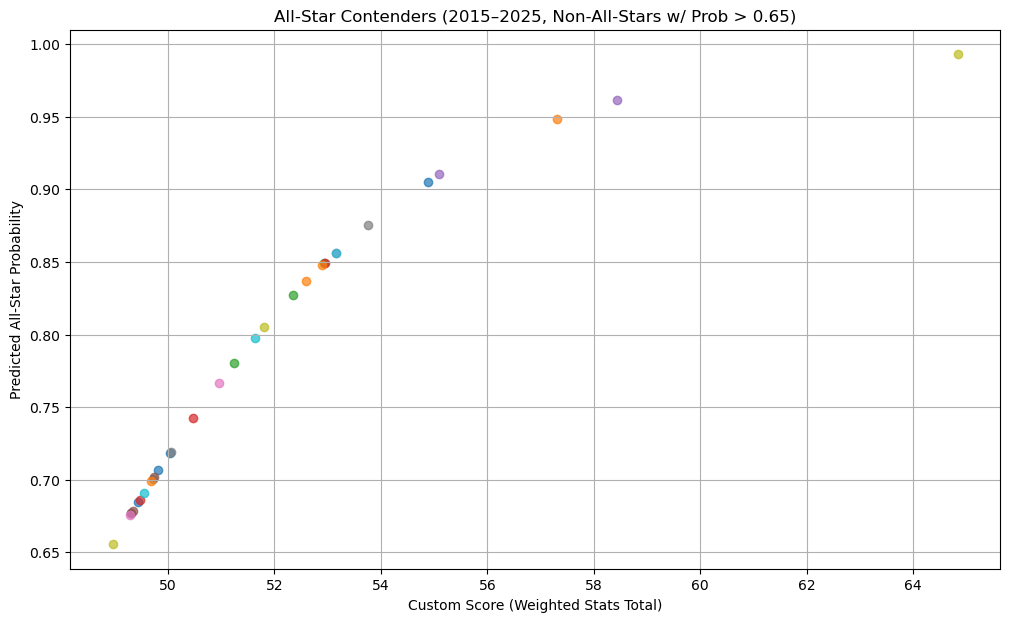

,Player,Year,Team,PTS,AST,TRB,STL,BLK,MP,CustomScore,AllStar_Prob
4013,Russell Westbrook,2021,WAS,22.2,11.7,11.5,1.4,0.4,36.4,64.84,0.993121
3045,Luka Dončić,2025,LAL,28.2,7.5,8.1,1.6,0.4,35.1,58.43,0.961763
1227,Domantas Sabonis,2024,SAC,19.4,8.2,13.7,0.9,0.6,35.7,57.31,0.948809
2001,James Harden,2023,PHI,21.0,10.7,6.1,1.2,0.5,36.8,55.10,0.910292
4457,Trae Young,2023,ATL,26.2,10.2,3.0,1.1,0.1,34.8,54.88,0.905272
2561,Karl-Anthony Towns,2020,MIN,26.5,4.4,10.8,0.9,1.2,33.9,53.75,0.875358
1023,DeMarcus Cousins,2015,SAC,24.1,3.6,12.7,1.5,1.7,34.1,53.15,0.856391
4455,Trae Young,2021,ATL,25.3,9.4,3.9,0.8,0.2,33.7,53.15,0.856391
1827,Ja Morant,2024,MEM,25.1,8.1,5.6,0.8,0.6,35.3,52.95,0.849554
408,Bradley Beal,2020,WAS,30.5,6.1,4.2,1.2,0.4,36.0,52.94,0.849206


In [100]:
# Contend

import matplotlib.pyplot as plt

# 1️⃣ Recalculate CustomScore if needed
df_labeled['CustomScore'] = (
    df_labeled['PTS'] * 1.0 +
    df_labeled['AST'] * 2.0 +
    df_labeled['TRB'] * 1.2 +
    df_labeled['STL'] * 1.0 +
    df_labeled['BLK'] * 1.0 +
    df_labeled['MP'] * 0.1
)

# 2️⃣ Predict All-Star probability using trained model
X_all = df_labeled[['CustomScore']]
df_labeled['AllStar_Prob'] = model.predict_proba(X_all)[:, 1]

# 3️⃣ Filter: Non-All-Stars with high predicted probability (e.g. > 0.65)
contenders = df_labeled[(df_labeled['AllStar'] == 0) & (df_labeled['AllStar_Prob'] > 0.65)]

# 4️⃣ Drop duplicate player-year to avoid overplotting
contenders = contenders.drop_duplicates(subset=['Player', 'Year'])

# 5️⃣ Plot contenders
plt.figure(figsize=(12, 7))
for _, row in contenders.iterrows():
    plt.scatter(row['CustomScore'], row['AllStar_Prob'], label=f"{row['Player']} ({row['Year']})", alpha=0.7)

plt.xlabel('Custom Score (Weighted Stats Total)')
plt.ylabel('Predicted All-Star Probability')
plt.title('All-Star Contenders (2015–2025, Non-All-Stars w/ Prob > 0.65)')
plt.grid(True)

# Optional: Hide legend if too cluttered
if len(contenders) <= 20:
    plt.legend()
plt.show()

# 6️⃣ Show top 100 contenders by CustomScore
top_contenders = contenders.sort_values(by='CustomScore', ascending=False).head(100)
top_contenders[['Player', 'Year', 'Team', 'PTS', 'AST', 'TRB', 'STL', 'BLK', 'MP', 'CustomScore', 'AllStar_Prob']]

In [101]:
# 📊 Cell 7: AdvancedScore using raw TS% and Total MP ≥ 500

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# ✅ Step 0: Compute total minutes played
df_labeled['TotalMP'] = df_labeled['G'] * df_labeled['MP']

# ✅ Step 1: Filter out players with low total minutes
print("➡️ Rows in df_labeled before TotalMP filter:", len(df_labeled))
print("➡️ Players with TotalMP ≥ 500:", (df_labeled['TotalMP'] >= 500).sum())

model_df = df_labeled[df_labeled['TotalMP'] >= 500].copy()

# ✅ Step 2: Compute AdvancedScore using raw TS%
model_df['AdvancedScore'] = (
    model_df['CustomScore'] +
    (model_df['TS%'] * 100) * 50 +
    model_df['TeamWins'] * 0.50
)

# ✅ Step 3: Drop rows with missing data
model_df = model_df.dropna(subset=['AdvancedScore', 'AllStar'])

# ✅ Step 4: Train/test split
X = model_df[['AdvancedScore']]
y = model_df['AllStar']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ✅ Step 5: Train model
advanced_model = LogisticRegression()
advanced_model.fit(X_train, y_train)

# ✅ Step 6: Evaluate performance
y_pred = advanced_model.predict(X_test)
print("✅ Logistic Regression with Raw TS% and TotalMP ≥ 500")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


➡️ Rows in df_labeled before TotalMP filter: 4795
➡️ Players with TotalMP ≥ 500: 3944
✅ Logistic Regression with Raw TS% and TotalMP ≥ 500
Accuracy: 0.9210526315789473
              precision    recall  f1-score   support

           0       0.92      1.00      0.96        70
           1       0.00      0.00      0.00         6

    accuracy                           0.92        76
   macro avg       0.46      0.50      0.48        76
weighted avg       0.85      0.92      0.88        76



c:\Users\mikey\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\mikey\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\mikey\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


C:\Users\mikey\AppData\Local\Temp\ipykernel_32356\2921120959.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


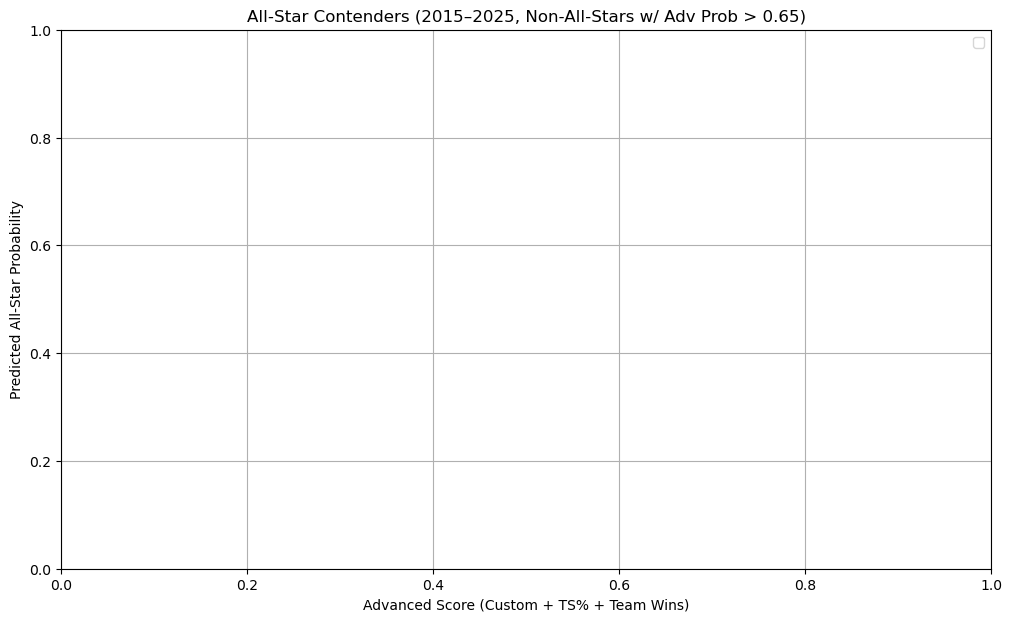

,Player,Year,Team,PTS,AST,TRB,STL,BLK,MP,TS%,TeamWins,AdvancedScore,AllStar_Prob_Adv


In [102]:
# 📊 Cell 8 – Contender analysis with AdvancedScore

# 1️⃣ Predict All-Star probability using advanced model
model_df['AllStar_Prob_Adv'] = advanced_model.predict_proba(model_df[['AdvancedScore']])[:, 1]

# 2️⃣ Filter: Non-All-Stars with high predicted probability
adv_contenders = model_df[(model_df['AllStar'] == 0) & (model_df['AllStar_Prob_Adv'] > 0.65)]

# 3️⃣ Drop duplicate player-year to avoid overplotting
adv_contenders = adv_contenders.drop_duplicates(subset=['Player', 'Year'])

# 4️⃣ Plot contenders
plt.figure(figsize=(12, 7))
for _, row in adv_contenders.iterrows():
    plt.scatter(row['AdvancedScore'], row['AllStar_Prob_Adv'], label=f"{row['Player']} ({row['Year']})", alpha=0.7)

plt.xlabel('Advanced Score (Custom + TS% + Team Wins)')
plt.ylabel('Predicted All-Star Probability')
plt.title('All-Star Contenders (2015–2025, Non-All-Stars w/ Adv Prob > 0.65)')
plt.grid(True)

# Optional: Show legend if manageable
if len(adv_contenders) <= 20:
    plt.legend()
plt.show()

# 5️⃣ Show top 100 contenders by AdvancedScore
top_adv_contenders = adv_contenders.sort_values(by='AdvancedScore', ascending=False).head(50)
top_adv_contenders[[
    'Player', 'Year', 'Team', 'PTS', 'AST', 'TRB', 'STL', 'BLK', 'MP',
    'TS%', 'TeamWins', 'AdvancedScore', 'AllStar_Prob_Adv'
]]


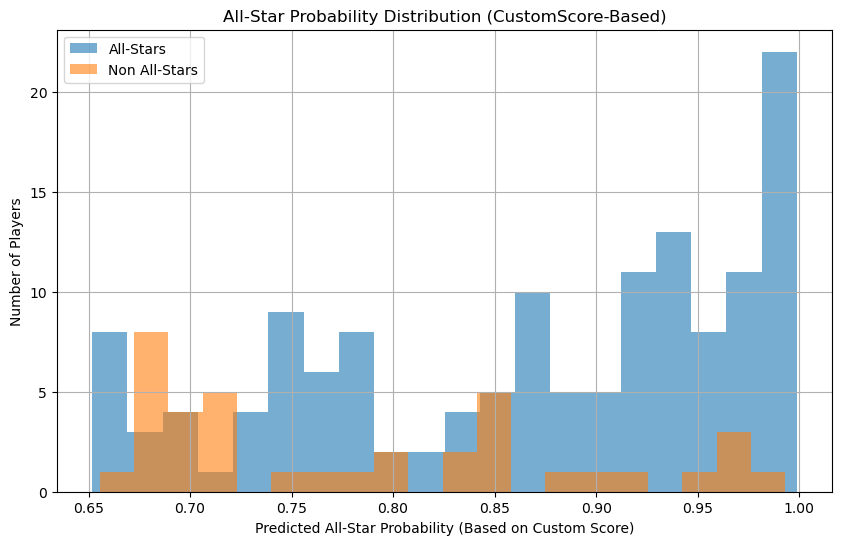

In [103]:
# All-Star Probability Distribution (Only players with probability > 0.2 using CustomScore)

import matplotlib.pyplot as plt

# Ensure probability column is using CustomScore-based model
df_labeled['AllStar_Prob'] = model.predict_proba(df_labeled[['CustomScore']])[:, 1]

# Filter players with predicted All-Star probability ≥ 0.65
high_prob = df_labeled[df_labeled['AllStar_Prob'] >= 0.65]

# Separate into actual All-Stars and Non-All-Stars
allstars = high_prob[high_prob['AllStar'] == 1]
non_allstars = high_prob[high_prob['AllStar'] == 0]

# Plot the histograms
plt.figure(figsize=(10, 6))
plt.hist(allstars['AllStar_Prob'], bins=20, alpha=0.6, label='All-Stars')
plt.hist(non_allstars['AllStar_Prob'], bins=20, alpha=0.6, label='Non All-Stars')
plt.xlabel('Predicted All-Star Probability (Based on Custom Score)')
plt.ylabel('Number of Players')
plt.title('All-Star Probability Distribution (CustomScore-Based)')
plt.legend()
plt.grid(True)
plt.show()



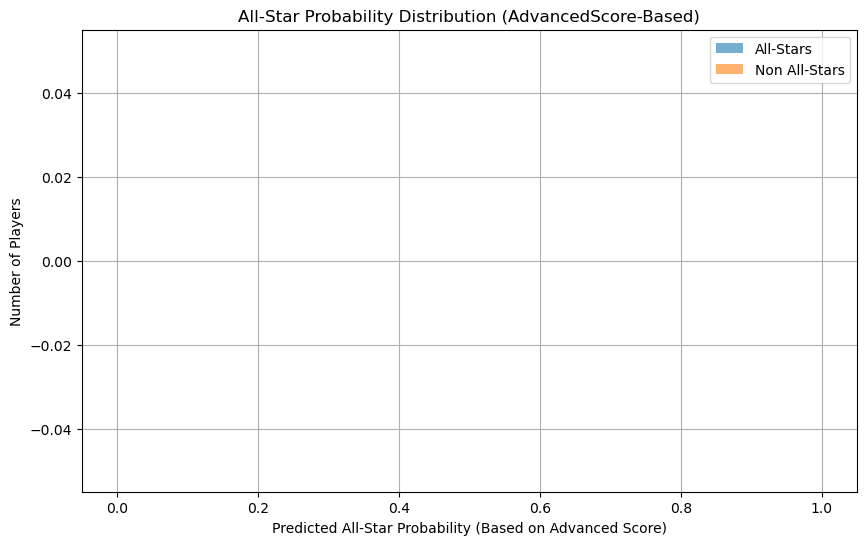

In [104]:
# All-Star Probability Distribution (Only players with probability > 0.2 using AdvancedScore)

import matplotlib.pyplot as plt

# Ensure you're using model_df (filtered for TotalMP ≥ 500)
model_df['AllStar_Prob'] = advanced_model.predict_proba(model_df[['AdvancedScore']])[:, 1]

# Filter players with predicted All-Star probability ≥ 0.65
high_prob = model_df[model_df['AllStar_Prob'] >= 0.65]

# Separate into actual All-Stars and Non-All-Stars
allstars = high_prob[high_prob['AllStar'] == 1]
non_allstars = high_prob[high_prob['AllStar'] == 0]

# Plot the histograms
plt.figure(figsize=(10, 6))
plt.hist(allstars['AllStar_Prob'], bins=20, alpha=0.6, label='All-Stars')
plt.hist(non_allstars['AllStar_Prob'], bins=20, alpha=0.6, label='Non All-Stars')
plt.xlabel('Predicted All-Star Probability (Based on Advanced Score)')
plt.ylabel('Number of Players')
plt.title('All-Star Probability Distribution (AdvancedScore-Based)')
plt.legend()
plt.grid(True)
plt.show()


In [105]:
# Show snubbed players custom

# Predict All-Star probability using only CustomScore
df_labeled['AllStar_Prob'] = model.predict_proba(df_labeled[['CustomScore']])[:, 1]

# Keep only players who were NOT All-Stars
potential_snubs = df_labeled[df_labeled['AllStar'] == 0]

# Filter: only players with predicted All-Star probability ≥ 0.2
snubs = potential_snubs[potential_snubs['AllStar_Prob'] >= 0.65]

# Show top 15 snubbed players by All-Star probability
snubs[['Player', 'Year', 'PTS', 'AST', 'TRB', 'MP', 'CustomScore', 'AllStar_Prob']] \
    .sort_values(by='AllStar_Prob', ascending=False).head(50)


,Player,Year,PTS,AST,TRB,MP,CustomScore,AllStar_Prob
4013,Russell Westbrook,2021,22.2,11.7,11.5,36.4,64.84,0.993121
3046,Luka Dončić,2025,28.2,7.5,8.1,35.1,58.43,0.961763
3047,Luka Dončić,2025,28.2,7.5,8.1,35.1,58.43,0.961763
3045,Luka Dončić,2025,28.2,7.5,8.1,35.1,58.43,0.961763
1227,Domantas Sabonis,2024,19.4,8.2,13.7,35.7,57.31,0.948809
2001,James Harden,2023,21.0,10.7,6.1,36.8,55.10,0.910292
4457,Trae Young,2023,26.2,10.2,3.0,34.8,54.88,0.905272
2561,Karl-Anthony Towns,2020,26.5,4.4,10.8,33.9,53.75,0.875358
1023,DeMarcus Cousins,2015,24.1,3.6,12.7,34.1,53.15,0.856391
4455,Trae Young,2021,25.3,9.4,3.9,33.7,53.15,0.856391


In [106]:
# Show snubbed players using AdvancedScore

# Predict All-Star probability using AdvancedScore-based model
model_df['AllStar_Prob'] = advanced_model.predict_proba(model_df[['AdvancedScore']])[:, 1]

# Keep only players who were NOT All-Stars
potential_snubs = model_df[model_df['AllStar'] == 0]

# Filter: only players with predicted All-Star probability ≥ 0.65
snubs = potential_snubs[potential_snubs['AllStar_Prob'] >= 0.65]

# Show top 50 snubbed players by All-Star probability
snubs[['Player', 'Year', 'Team', 'PTS', 'AST', 'TRB', 'MP', 'AdvancedScore', 'AllStar_Prob']] \
    .sort_values(by='AllStar_Prob', ascending=False).head(50)


,Player,Year,Team,PTS,AST,TRB,MP,AdvancedScore,AllStar_Prob


In [107]:
# Test Player 


# Define the custom player's stats
custom_stats = {
    'PTS': 15.5,
    'AST': 11.5,
    'TRB': 3.3,
    'STL': 1.0,
    'BLK': 0.1,
    'MP': 34.3
}

# Calculate custom score using the same weights
custom_score = (
    custom_stats['PTS'] * 1.0 +
    custom_stats['AST'] * 2.0 +
    custom_stats['TRB'] * 1.2 +
    custom_stats['STL'] * 1.0 +
    custom_stats['BLK'] * 1.0 +
    custom_stats['MP'] * 0.1
)

# Create DataFrame for prediction
custom_input = pd.DataFrame({'CustomScore': [custom_score]})

# Predict All-Star status based on custom score
prediction = model.predict(custom_input)
probability = model.predict_proba(custom_input)[0, 1]

# Show result
print(f"Custom Score: {custom_score:.2f}")
print("All-Star Prediction:", "⭐ YES!" if prediction[0] == 1 else "❌ Nope.")
print(f"Predicted Probability: {probability:.2%}")


Custom Score: 46.99
All-Star Prediction: ⭐ YES!
Predicted Probability: 52.66%


In [108]:
# Test Custom Player using AdvancedScore


import pandas as pd

# Define the custom player's stats
custom_stats = {
    'PTS': 15.5,
    'AST': 11.5,
    'TRB': 3.3,
    'STL': 1.0,
    'BLK': 0.1,
    'MP': 34.3,
    'TS%': 0.61,
    'TeamWins': 62
}

# Calculate AdvancedScore using your weights
advanced_score = (
    custom_stats['PTS'] * 1.0 +
    custom_stats['AST'] * 2.0 +
    custom_stats['TRB'] * 1.2 +
    custom_stats['STL'] * 1.0 +
    custom_stats['BLK'] * 1.0 +
    custom_stats['MP'] * 0.1 +
    custom_stats['TS%'] * 50 +       # Weight for TS%
    custom_stats['TeamWins'] * .50  # Weight for Team Wins
)

# Create DataFrame for prediction
custom_input = pd.DataFrame({'AdvancedScore': [advanced_score]})

# Predict All-Star status based on AdvancedScore
prediction = advanced_model.predict(custom_input)
probability = advanced_model.predict_proba(custom_input)[0, 1]

# Show result
print(f"Advanced Score: {advanced_score:.2f}")
print("All-Star Prediction:", "⭐ YES!" if prediction[0] == 1 else "❌ Nope.")
print(f"Predicted Probability: {probability:.2%}")


Advanced Score: 108.49
All-Star Prediction: ❌ Nope.
Predicted Probability: 0.00%
